## Generate Synthetic images

## Step-1 : Import the necessaery libraries

In [1]:
import cv2
import numpy as np
from skimage.feature import canny
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt


## Step-2 Generate Synthetic images

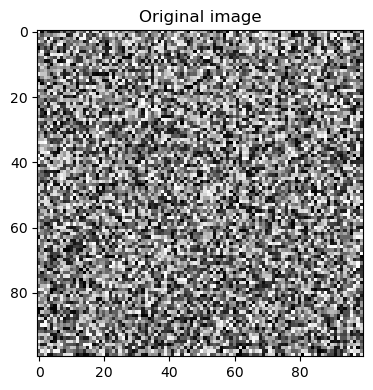

In [16]:
#Generate Synthetic images
images = [np.random.rand(100,100) for _ in range(100) ] 

#Displaying image
plt.figure(figsize=(4,4))
plt.imshow(images[0],cmap='gray')
plt.title('Original image')
#plt.axis('off')
plt.tight_layout()
plt.show()

## Step-3 : Preprocesing the blur

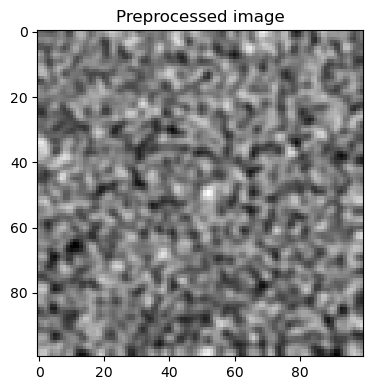

In [17]:
preprocessed_images = [cv2.GaussianBlur(img, (5, 5), 0) for img in images]

#Displaying image
plt.figure(figsize=(4,4))
plt.imshow(preprocessed_images[0],cmap='gray')
plt.title('Preprocessed image')
#plt.axis('off')
plt.tight_layout()
plt.show()

## Step-4 : Segmentation (Canny edge detection)


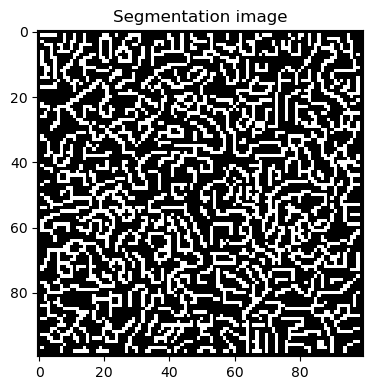

In [18]:
edges = [canny(img) for img in preprocessed_images]

#Displaying image
plt.figure(figsize=(4,4))
plt.imshow(edges[0],cmap='gray')
plt.title('Segmentation image')
#plt.axis('off')
plt.tight_layout()
plt.show()

## Step-5 : Feature Extraction and detection (region properties)



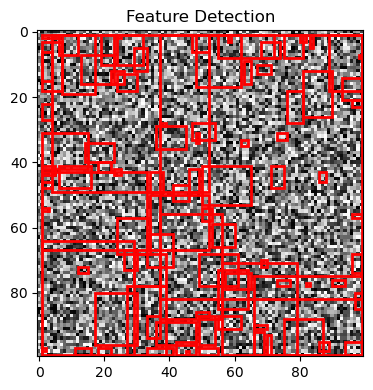

In [24]:
features = [regionprops(label(edge)) for edge in edges]

# Displaying image with detected features
fig, ax = plt.subplots(figsize=(4, 4))

# Show the image
ax.imshow(images[0], cmap='gray')

# Add rectangles for each detected feature
for region in features[0]:
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle((minc, minr), 
                         maxc - minc, 
                         maxr - minr, 
                         edgecolor='red', 
                         facecolor='none', 
                         linewidth=2)
    ax.add_patch(rect)  # Fixed: Use ax.add_patch() not plt.add_patch()

ax.set_title('Feature Detection')
# ax.axis('off')  # Uncomment if you don't want axes
plt.tight_layout()
plt.show()

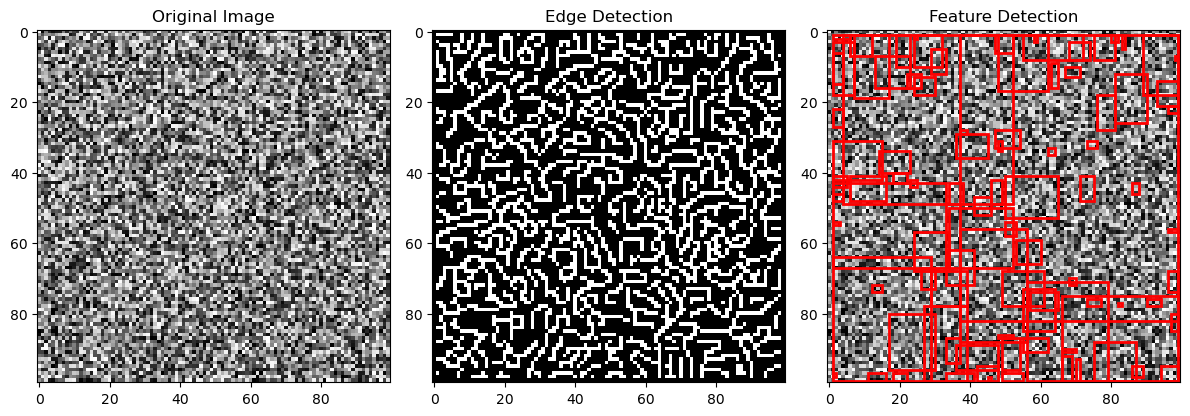

In [25]:
# Display sample image, edges, and detected features
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(images[0], cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(edges[0], cmap='gray')
ax[1].set_title('Edge Detection')
ax[2].imshow(images[0], cmap='gray')
for region in features[0]:
    minr, minc, maxr, maxc = region.bbox
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr, edgecolor='red', facecolor='none', linewidth=2)
    ax[2].add_patch(rect)

ax[2].set_title('Feature Detection')
plt.tight_layout()
plt.show()